# __Modelado predictivo del desempeño de empleados__

Construye y evalua modelos predictivos para estimar el desempeño de los empleados. Se buscar predecir la variable KPIs_met_more_than_80 (si un empleado cumple más del 80% de sus KPIs) a partir de variables como departamento, región, educación, género, entrenamientos recibidos, edad, calificación del año anterior, antigüedad, premios ganados y puntaje promedio de entrenamiento.

Se usan como modelos la _Regresión Logística_ ya que es una tarea de clasificación binaria y el _Modelo de Apilamiento_ ya que combina las fortalezas de un arbol de decisión y una SVM.

## Librerías

In [1]:
# librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve

# modelo de apilamiento
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score

In [2]:
# Estilo de graficas
sns.set_theme(style="whitegrid")

## Carga de datos limpios

In [3]:
# Cargamos el dataset ya limpio, generado en 01_limpieza_datos.ipynb
# Ruta corregida: el dataset se movio a la carpeta 'data/' tras la reorganizacion del repositorio
data = pd.read_csv('../data/employees_cleaned.csv')
data

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,f,other,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,m,other,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,f,other,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,m,sourcing,1,36,3.0,2,0,0,68
...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Sales & Marketing,31,Bachelors,m,other,1,42,3.0,10,0,0,53
15412,Sales & Marketing,25,Bachelors,m,sourcing,2,28,2.0,5,0,0,45
15413,Technology,7,Bachelors,f,referred,2,30,5.0,6,1,0,81
15414,HR,7,Bachelors,m,other,1,33,1.0,9,0,0,51


## Procesamiento de la data


### Copia de los datos

In [4]:
# Creamos una copia de los datos
df = data.copy()
df

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,f,other,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,m,other,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,f,other,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,m,sourcing,1,36,3.0,2,0,0,68
...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Sales & Marketing,31,Bachelors,m,other,1,42,3.0,10,0,0,53
15412,Sales & Marketing,25,Bachelors,m,sourcing,2,28,2.0,5,0,0,45
15413,Technology,7,Bachelors,f,referred,2,30,5.0,6,1,0,81
15414,HR,7,Bachelors,m,other,1,33,1.0,9,0,0,51


### Eliminar variables no relevantes

In [5]:
# Eliminamos la variable categorica 'recruitment_channel' por su baja correlacion con la variable target.
df = df.drop(['recruitment_channel'], axis=1)
df

,department,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,f,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,m,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,f,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,m,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,m,1,36,3.0,2,0,0,68
...,...,...,...,...,...,...,...,...,...,...,...
15411,Sales & Marketing,31,Bachelors,m,1,42,3.0,10,0,0,53
15412,Sales & Marketing,25,Bachelors,m,2,28,2.0,5,0,0,45
15413,Technology,7,Bachelors,f,2,30,5.0,6,1,0,81
15414,HR,7,Bachelors,m,1,33,1.0,9,0,0,51


### Convertir variables categóricas a numéricas

In [6]:
# creamos una clase LabelEncoder
le = LabelEncoder()

# pasamos la variable a convertir a la clase antes definida
df['gender'] = le.fit_transform(df['gender'])

# mostramos resultados
df.head()

,department,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,0,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,1,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,0,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,1,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,1,1,36,3.0,2,0,0,68


In [7]:
# Seleccion de variables predictoras
X = df.drop('KPIs_met_more_than_80', axis=1).values

# Seleccion de variable objetivo
y = df['KPIs_met_more_than_80'].values

X

array([['HR', 4, 'Bachelors', ..., 5, 0, 51],
       ['Sales & Marketing', 13, 'Bachelors', ..., 4, 0, 47],
       ['Procurement', 2, 'Bachelors', ..., 9, 0, 65],
       ...,
       ['Technology', 7, 'Bachelors', ..., 6, 0, 81],
       ['HR', 7, 'Bachelors', ..., 9, 0, 51],
       ['HR', 7, 'Bachelors', ..., 4, 0, 81]], dtype=object)

In [8]:
# codificamos tanto 'department' (indice 0) como 'education' (indice 2) con OneHot
# Transformer
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0, 2])], remainder='passthrough')

# Aplicamos el Transformer sobre las variables predictoras
X = np.array(ct.fit_transform(X))

X

array([[0.0, 0.0, 1.0, ..., 5, 0, 51],
       [0.0, 0.0, 0.0, ..., 4, 0, 47],
       [0.0, 0.0, 0.0, ..., 9, 0, 65],
       ...,
       [0.0, 0.0, 0.0, ..., 6, 0, 81],
       [0.0, 0.0, 1.0, ..., 9, 0, 51],
       [0.0, 0.0, 1.0, ..., 4, 0, 81]], dtype=object)

### Selección de features relevantes

In [9]:
# reconstruimos los nombres de las features en el mismo orden en que quedaron en X
onehot_feature_names = (
    [f'department_{cat}' for cat in ct.named_transformers_['encoder'].categories_[0]] +
    [f'education_{cat}' for cat in ct.named_transformers_['encoder'].categories_[1]]
)
remainder_feature_names = ['region', 'gender', 'no_of_trainings', 'age',
       'previous_year_rating', 'length_of_service', 'awards_won', 'avg_training_score']

feature_names = onehot_feature_names + remainder_feature_names

# usamos SelectKBest para seleccionar las 5 variables con mas influencia sobre target
selector = SelectKBest(score_func=f_regression, k=5)
# ajustamos el selector a los datos
selector.fit(X,y)

SelectKBest(k=5, score_func=<function f_regression at 0x706d5997cca0>)

In [10]:
# Obtenemos la matriz de features transformada
X_selected = selector.transform(X)
X_selected

array([[0.0, 0.0, 3.0, 5, 0],
       [0.0, 1.0, 1.0, 4, 0],
       [0.0, 0.0, 2.0, 9, 0],
       ...,
       [0.0, 0.0, 5.0, 6, 0],
       [0.0, 0.0, 1.0, 9, 0],
       [0.0, 0.0, 5.0, 4, 0]], dtype=object)

In [11]:
# obtenemos el indice de los features seleccionados
selected_indices = selector.get_support(indices=True)
selected_indices

array([ 4,  7, 16, 17, 18])

In [12]:
# obtenemos los nombres de los features seleccionados de la lista de nombre de las variables originales
selected_features_names = [feature_names[idx] for idx in selected_indices]

# mostramos features
print('Top nombre de los features seleccionados:')
print(selected_features_names)

Top nombre de los features seleccionados:
['department_Operations', 'department_Sales & Marketing', 'previous_year_rating', 'length_of_service', 'awards_won']


### Dividir los datos en entrenamiento y de prueba

In [13]:
# dividimos los datos en dos grupos y guardamos en variables
# test_size: indica el tamano del grupo de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [14]:
X_train

array([[0.0, 0.0, 0.0, ..., 13, 0, 59],
       [0.0, 0.0, 0.0, ..., 2, 0, 58],
       [0.0, 0.0, 0.0, ..., 5, 0, 73],
       ...,
       [0.0, 0.0, 0.0, ..., 3, 0, 51],
       [0.0, 1.0, 0.0, ..., 5, 0, 63],
       [0.0, 0.0, 0.0, ..., 3, 0, 60]], dtype=object)

Los valores de entrenamiento no están normalizados. ¡Vamos a normalizarlo!

In [15]:
# Creamos el objeto Scalador
sc = StandardScaler()

# Normalizamos los valores de entrenamiento y de prueba
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

X_train

array([[-0.32084652, -0.22114935, -0.22733242, ...,  1.62112741,
        -0.15736318, -0.32996384],
       [-0.32084652, -0.22114935, -0.22733242, ..., -1.03112885,
        -0.15736318, -0.40496088],
       [-0.32084652, -0.22114935, -0.22733242, ..., -0.30778623,
        -0.15736318,  0.71999464],
       ...,
       [-0.32084652, -0.22114935, -0.22733242, ..., -0.79001464,
        -0.15736318, -0.92994012],
       [-0.32084652,  4.5218311 , -0.22733242, ..., -0.30778623,
        -0.15736318, -0.0299757 ],
       [-0.32084652, -0.22114935, -0.22733242, ..., -0.79001464,
        -0.15736318, -0.25496681]])

## Modelo de clasificación

Vamos a utilizar el modelo de regresión logística.

In [16]:
# creamos un objeto con el modelo
classifier_lg = LogisticRegression(random_state=0)

# ajustamos el modelo a los datos de entrenamiento
classifier_lg.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [17]:
# Creamos el predictor
y_pred = classifier_lg.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 1])

Calculamos algunas métricas descriptivas del modelo.

In [18]:
# Calculo de la exactitud
accuracy_lg = accuracy_score(y_test, y_pred)*100
# Calculo de la precision
precision_lg = precision_score(y_test, y_pred)*100
# Calculo puntaje del modelo
score_lg = f1_score(y_test,y_pred)*100
# Calculo recuperacion del modelo
recall_lg = recall_score(y_test,y_pred)*100

print('-------Metricas del modelo de Regresion Logistica----------')
print('Exactitud: ',accuracy_lg)
print('Precision: ',precision_lg)
print('Puntaje del modelo: ',score_lg)
print('Recuperacion: ',recall_lg)

-------Metricas del modelo de Regresion Logistica----------
Exactitud:  70.23346303501945
Precision:  60.48192771084337
Puntaje del modelo:  52.2372528616025
Recuperacion:  45.97069597069597


Creamos la matriz de confusión.

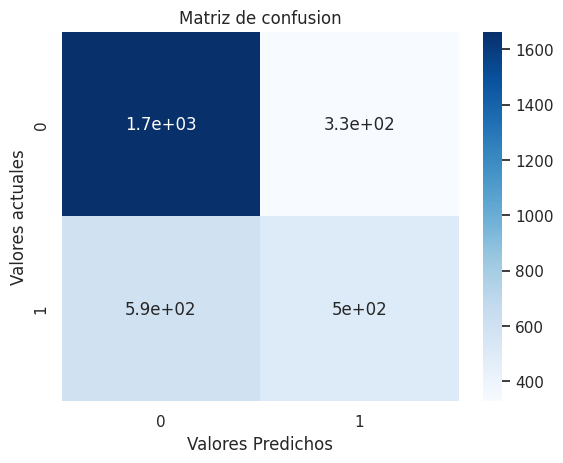

In [19]:
# Calculo de la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

# creamos el heatmap de la matriz de confusion
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Valores Predichos')
plt.ylabel('Valores actuales')
plt.title('Matriz de confusion');

## Curva de recuperación de la precisión del modelo

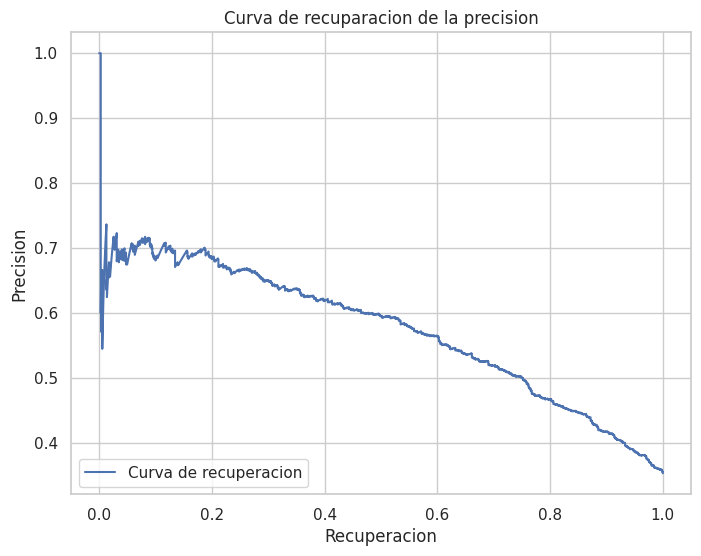

In [20]:
# tenemos el modelo lg y la data de prueba X_test, y_test
# obtenemos las estimaciones de probabilidad de la clase positiva
y_scores = classifier_lg.predict_proba(X_test)[:,1]

# obtenemos valores de los parametros
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Graficamos la curva
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Curva de recuperacion')
plt.xlabel('Recuperacion')
plt.ylabel('Precision')
plt.title('Curva de recuparacion de la precision')
plt.legend(loc='lower left');

## Modelo de apilamiento

In [21]:
# Estimadores base
base_learners = [
    ('rf_1', DecisionTreeClassifier()),
    ('rf_2', SVC())
]

# Meta modelo
logreg = LogisticRegression()

# Clasificador de apilamiento
stack_clf = StackingClassifier(estimators=base_learners, final_estimator=logreg)

# entrenamiento del modelo
stack_clf.fit(X_train, y_train)

# Crear la prediccion
y_pred_stack = stack_clf.predict(X_test)

In [22]:
# obtener los parametros del modelo
accuracy_stack = accuracy_score(y_test, y_pred_stack)*100
precision_stack = precision_score(y_test, y_pred_stack)*100
score_stack = f1_score(y_test, y_pred_stack)*100
recall_stack = recall_score(y_test, y_pred_stack)*100

print('-------Metricas del modelo de Apilamiento----------')
print('Exactitud: ',accuracy_stack)
print('Precision: ',precision_stack)
print('Puntaje del modelo: ',score_stack)
print('Recuperacion: ',recall_stack)

-------Metricas del modelo de Apilamiento----------
Exactitud:  70.71984435797665
Precision:  65.56836902800659
Puntaje del modelo:  46.851088875809296
Recuperacion:  36.446886446886445


## Curva operativa característica del receptor

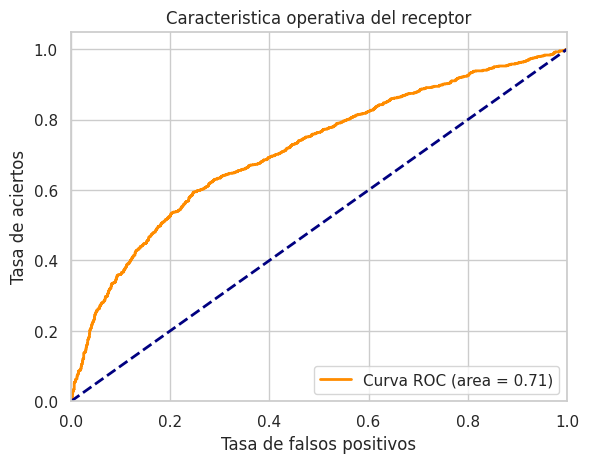

In [23]:
# ajustamos el modelos a los datos de entrenamiento
stack_clf.fit(X_train, y_train)

# predecimos las probabilidades de la clase positiva
y_prob = stack_clf.predict_proba(X_test)[:,1]

# Calculamos la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Graficamos la curva
plt.figure
lw=2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='Curva ROC (area = %0.2f)' %roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de aciertos')
plt.title('Caracteristica operativa del receptor')
plt.legend(loc="lower right");

## Validación cruzada de la regresión logística

In [24]:
# calculo de la validacion cruzada
accuracies = cross_val_score(estimator=classifier_lg, X=X_train, y=y_train, cv=10)

# mostrar valores
print('Precision: {:.2f} %'.format(accuracies.mean()*100))
print('Desviacion Estandar: {:.2f} %'.format(accuracies.std()*100))

Precision: 70.82 %
Desviacion Estandar: 1.31 %


## Evaluación de los modelos

In [25]:
# definimos los nombres de los modelos y sus respectivos valores de precision
model_names = ['Logistic Regression', 'Stack: Logistic Regression']
accuracy_values = [accuracy_lg, accuracy_stack]
precision_values = [precision_lg, precision_stack]
f1_score_values = [score_lg, score_stack]
recall_values = [recall_lg, recall_stack]

# creamos un diccionario con la data antes seleccionada
data = {'Model': model_names,
        'Accuracy': accuracy_values,
        'Precision': precision_values,
        'Recall': recall_values,
        'f1_score': f1_score_values}

# Creamos un dataframe con los datos
df = pd.DataFrame(data)

# mostrar resultados
df

,Model,Accuracy,Precision,Recall,f1_score
0,Logistic Regression,70.233463,60.481928,45.970696,52.237253
1,Stack: Logistic Regression,70.719844,65.568369,36.446886,46.851089


## Conclusiones

**Experimento: inclusión de `department`**

El EDA (`02_analisis_exploratorio.ipynb`) identificó al departamento como el factor más explicativo del cumplimiento de KPIs, pero la versión original de este notebook lo eliminaba del modelo sin justificación. Se corrigió esto manteniendo `department` (codificado con `OneHotEncoder`, igual que `education`) y se volvió a entrenar y evaluar ambos modelos. Resultado, comparado con la versión anterior (sin `department`):

| Modelo | Métrica | Sin `department` | Con `department` | Cambio |
|---|---|---|---|---|
| Regresión Logística | Exactitud | 70.30% | 70.23% | ≈ igual |
| Regresión Logística | F1-score | 52.09% | 52.24% | ≈ igual |
| Apilamiento | Exactitud | 70.75% | 70.82% | ≈ igual |
| Apilamiento | Precisión | 62.57% | 65.95% | ↑ mejora |
| Apilamiento | Recall | 43.32% | 36.36% | ↓ empeora notablemente |
| Apilamiento | F1-score | 51.19% | 46.87% | ↓ empeora |

- `SelectKBest` ahora incluye dos categorías de `department` (`Operations` y `Sales & Marketing`) entre las 5 features más predictivas, desplazando a `no_of_trainings` y `avg_training_score`.
- La regresión logística prácticamente no cambia al incluir `department`.
- El modelo de apilamiento empeora en recall y F1-score pese a mejorar su precisión: se vuelve más conservador prediciendo la clase positiva.
- **Conclusión clave**: que `department` sea el factor más explicativo en un análisis univariado/bivariado (EDA) no implica que aporte poder predictivo adicional en un modelo multivariado. Su información puede solaparse con variables ya incluidas que varían por departamento (p. ej. `avg_training_score`, que el EDA mostró como bimodal según el tipo de departamento), y su codificación one-hot (9 categorías) añade dimensionalidad que no benefició a los estimadores base del apilamiento (`DecisionTreeClassifier`, `SVC`) sin un ajuste de hiperparámetros adicional.

**Otros hallazgos**

- Ambos modelos siguen teniendo un desempeño similar en exactitud (~70%); ninguno domina claramente al otro.
- El recall del modelo de apilamiento (36.4%) es ahora considerablemente más bajo, por lo que deja sin detectar a una proporción aún mayor de empleados que sí cumplen sus KPIs.
- La validación cruzada de 10 folds sobre la regresión logística confirma estabilidad: 70.82% ± 1.31%.

> Dado que incluir `department` no mejora—y en el caso del apilamiento, empeora—el desempeño predictivo, la **regresión logística sin `department` (o con `department` como aquí, ya que el cambio es marginal) sigue siendo la opción más simple y efectiva**. Un siguiente paso razonable sería explorar `target encoding` para `department` o un ajuste de hiperparámetros del modelo de apilamiento antes de descartar definitivamente su aporte.